<a href="https://colab.research.google.com/github/Sameer0Rai/Deep-Learning/blob/main/Lab-Assignments/Lab_2_Perceptron_vs__LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Name : Yash Tyagi
#Roll Number : 102303683
#SubGroup : 3C54
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
a = 8   # second last digit
b = 3    # last digit

min_points = 30 + a
extra_points = 20                  # added intentionally
samples_per_class = min_points + extra_points

sigma = 0.01 * a                   # noise standard deviation
angle_deg = 15 * b                 # rotation angle
angle_rad = np.deg2rad(angle_deg)

np.random.seed(10)                 # reproducibility


class_A = np.random.randn(samples_per_class, 2) + np.array([-2, 0])
class_B = np.random.randn(samples_per_class, 2) + np.array([2, 0])


rotation = np.array([
    [np.cos(angle_rad), -np.sin(angle_rad)],
    [np.sin(angle_rad),  np.cos(angle_rad)]
])

class_B = class_B @ rotation.T

features = np.vstack((class_A, class_B))
features += np.random.normal(0, sigma, features.shape)

labels = np.concatenate((
    np.zeros(samples_per_class),
    np.ones(samples_per_class)
))

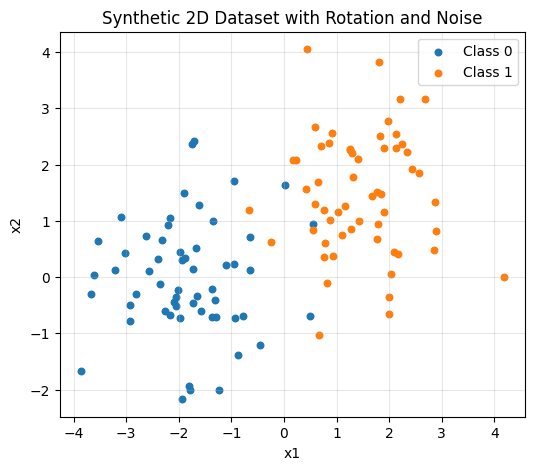

In [17]:
plt.figure(figsize=(6, 5))
plt.scatter(features[labels == 0, 0], features[labels == 0, 1],
            label="Class 0", s=22)
plt.scatter(features[labels == 1, 0], features[labels == 1, 1],
            label="Class 1", s=22)
plt.title("Synthetic 2D Dataset with Rotation and Noise")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
perc_clf = Perceptron(eta0=0.1, max_iter=1000, tol=None)
perc_clf.fit(features, labels)

log_clf = LogisticRegression()
log_clf.fit(features, labels)


x_lo, x_hi = features[:, 0].min() - 1, features[:, 0].max() + 1
y_lo, y_hi = features[:, 1].min() - 1, features[:, 1].max() + 1

gx, gy = np.meshgrid(
    np.linspace(x_lo, x_hi, 400),
    np.linspace(y_lo, y_hi, 400)
)

grid_points = np.c_[gx.ravel(), gy.ravel()]

perc_pred = perc_clf.predict(grid_points).reshape(gx.shape)
log_pred = log_clf.predict(grid_points).reshape(gx.shape)

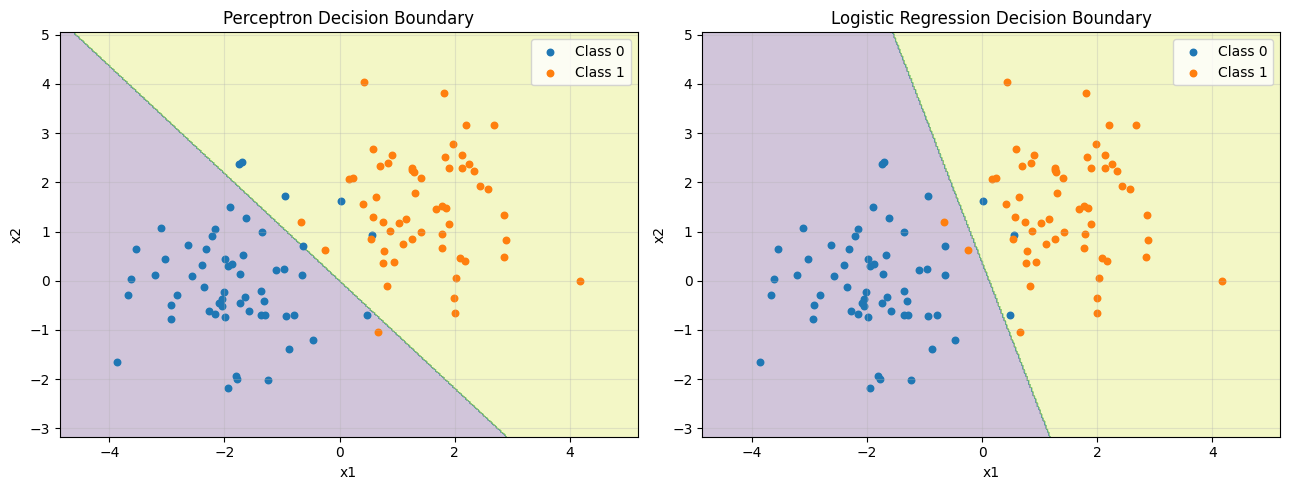

In [19]:
plt.figure(figsize=(13, 5))

# Perceptron
plt.subplot(1, 2, 1)
plt.contourf(gx, gy, perc_pred, alpha=0.25)
plt.scatter(features[labels == 0, 0], features[labels == 0, 1],
            label="Class 0", s=22)
plt.scatter(features[labels == 1, 0], features[labels == 1, 1],
            label="Class 1", s=22)
plt.title("Perceptron Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.3)

# Logistic Regression
plt.subplot(1, 2, 2)
plt.contourf(gx, gy, log_pred, alpha=0.25)
plt.scatter(features[labels == 0, 0], features[labels == 0, 1],
            label="Class 0", s=22)
plt.scatter(features[labels == 1, 0], features[labels == 1, 1],
            label="Class 1", s=22)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
perc_train_pred = perc_clf.predict(features)
log_train_pred = log_clf.predict(features)

perc_mis = perc_train_pred != labels
log_mis = log_train_pred != labels

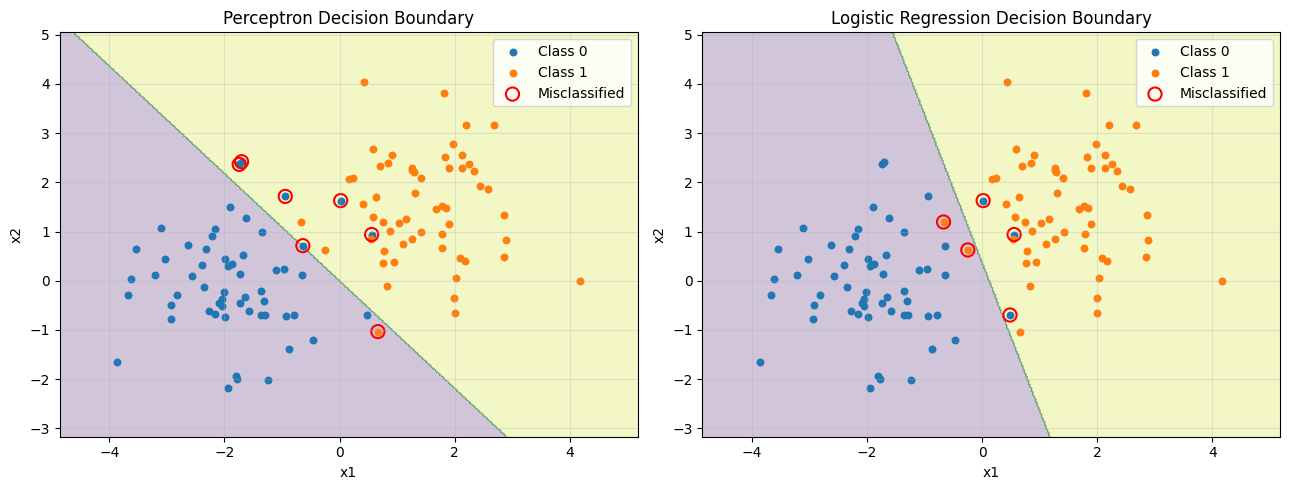

In [21]:
plt.figure(figsize=(13, 5))


plt.subplot(1, 2, 1)
plt.contourf(gx, gy, perc_pred, alpha=0.25)

# Correct points
plt.scatter(features[labels == 0, 0], features[labels == 0, 1],
            label="Class 0", s=22)
plt.scatter(features[labels == 1, 0], features[labels == 1, 1],
            label="Class 1", s=22)

# Misclassified points
plt.scatter(features[perc_mis, 0], features[perc_mis, 1],
            facecolors='none', edgecolors='red',
            s=90, linewidths=1.5, label="Misclassified")

plt.title("Perceptron Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.contourf(gx, gy, log_pred, alpha=0.25)

# Correct points
plt.scatter(features[labels == 0, 0], features[labels == 0, 1],
            label="Class 0", s=22)
plt.scatter(features[labels == 1, 0], features[labels == 1, 1],
            label="Class 1", s=22)

# Misclassified points
plt.scatter(features[log_mis, 0], features[log_mis, 1],
            facecolors='none', edgecolors='red',
            s=90, linewidths=1.5, label="Misclassified")

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()